# Track A · Phase 1 — A GPT From Scratch, on Your Mac

**Goal of this notebook:** build and train a small GPT language model *from nothing* — no pre-trained weights, no high-level training library — so you can see every moving part: how text becomes numbers (tokenization), how attention works, how a training loop drives the loss down, and how the trained model generates new text.

The output here is **deliberately throwaway quality**. A character-level model this small, trained for a few minutes, will produce text that *looks* like English but is mostly nonsense. That's the point: Track A is for *understanding*. The useful model comes in Track B (TrialScout), where we fine-tune a real pre-trained model.

**How to read this notebook:** top to bottom. Every code cell has narration above it explaining *why*. At the end there are "Try this" levers — change a number, re-run, watch what moves. That's how the intuition sticks.

Runs on Apple MLX (your M5 GPU). Nothing here needs the internet except the one dataset download.

## 1. Setup

We import [MLX](https://ml-explore.github.io/mlx/) — Apple's array/neural-net framework, the local equivalent of PyTorch. `mlx.core` (`mx`) is the array library (like `numpy` but GPU-accelerated on Apple Silicon); `mlx.nn` holds neural-net building blocks; `mlx.optimizers` has the optimizer (the thing that adjusts the model's weights).

In [1]:
import math, time
import numpy as np
import mlx.core as mx
import mlx.nn as nn
import mlx.optimizers as optim
from mlx.utils import tree_flatten
import matplotlib.pyplot as plt

print("MLX device:", mx.default_device())   # should say Device(gpu, 0) on your M5

MLX device: Device(gpu, 0)


## 2. Data — turning text into numbers

A model can't read letters; it reads integers. **Tokenization** is the map from text to integers and back.

We use the simplest possible scheme: **character-level**. Every distinct character (`a`, `b`, ` `, `.`, …) gets an integer id. `stoi` maps string→int, `itos` maps int→string. Real models use *sub-word* tokenization (BPE) — chunks like `"ing"` or `" the"` — which we'll meet in Track B. Character-level is less efficient but maximally transparent: you can see exactly what the model sees.

Our text is [**TinyStories**](https://huggingface.co/datasets/roneneldan/TinyStories) — a dataset of very simple, short children's stories written with a tiny vocabulary. It was designed precisely so that *small* models can learn coherent English from it. We stream a few thousand stories (no full download).

In [2]:
# Pull a few thousand TinyStories. Streaming = we don't download the whole dataset.
N_STORIES = 4000
try:
    from datasets import load_dataset
    ds = load_dataset("roneneldan/TinyStories", split="train", streaming=True)
    stories = []
    for i, ex in enumerate(ds):
        stories.append(ex["text"].strip())
        if len(stories) >= N_STORIES:
            break
    text = "\n\n".join(stories)
    print(f"Loaded {len(stories)} stories from TinyStories.")
except Exception as e:
    # Fallback so the notebook never hard-fails (e.g. offline). Tiny + repetitive.
    print("Dataset load failed, using fallback corpus. Reason:", e)
    text = ("Once upon a time there was a little girl who lived near a big forest. "
            "Every day she walked to the river and played with her friend the fox. "
            "They liked to watch the birds and tell happy stories. ") * 2000
    stories = [text[:300]]

print(f"Total characters: {len(text):,}")
# Show one COMPLETE story rather than the first 300 characters, so the shape of a single
# training example is obvious. Any index works; this one is a charmer.
SAMPLE = 1
print(f"---- sample: story #{SAMPLE} of {len(stories):,} ----")
print(stories[SAMPLE][:300])

Loaded 4000 stories from TinyStories.
Total characters: 3,394,018
---- sample: story #1 of 4,000 ----
Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.

One day, Beep was driving in the park when he saw a big tree. The tree had many leaves that were falling. Bee


Now we build the vocabulary and encode the entire corpus into one long array of integers. We hold out the last 10% as a **validation set** — text the model never trains on — so we can tell whether it's genuinely learning the language versus just memorizing the training text (the difference between *learning* and *overfitting*).

In [3]:
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}

def encode(s): return [stoi[c] for c in s]
def decode(ids): return "".join(itos[int(i)] for i in ids)

data = np.array(encode(text), dtype=np.int32)
n_train = int(0.9 * len(data))
train_data, val_data = data[:n_train], data[n_train:]

print(f"vocab_size = {vocab_size} distinct characters")
print(f"the vocab:  {''.join(chars)!r}")
print(f"train tokens = {len(train_data):,}   val tokens = {len(val_data):,}")
print(f'encode("hi") = {encode("hi")}  ->  decode back = {decode(encode("hi"))!r}')

vocab_size = 90 distinct characters
the vocab:  '\n !"$\',-.0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz¡¦©«±³»ÂÃâœ˜“”€™'
train tokens = 3,054,616   val tokens = 339,402
encode("hi") = [55, 56]  ->  decode back = 'hi'


**Batching.** We train on many short windows of text at once. `block_size` is the context length — how many characters the model sees before predicting the next one. For each window `x`, the target `y` is the *same window shifted by one*: at every position, the model's job is "given the characters so far, predict the next one." `get_batch` grabs `batch_size` random windows and stacks them.

In [4]:
def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = np.random.randint(0, len(d) - block_size - 1, size=batch_size)
    x = np.stack([d[i : i + block_size] for i in ix])
    y = np.stack([d[i + 1 : i + 1 + block_size] for i in ix])  # shifted by one
    return mx.array(x), mx.array(y)

## 3. Hyperparameters — every knob, with a note

These are the dials that define the model and the training run. **No magic numbers:** each has a comment on what it does and which way to push it. The "Try this" section at the end has you change some and observe.

In [5]:
# --- reproducibility ---
# Seed both generators this notebook draws from: MLX initialises the weights, NumPy picks
# the training batches. Without this, every re-run trains a different model AND re-rolls the
# sample text below it — so the outputs committed here could never be reproduced. Same fix as
# notebook 02; see docs/DECISIONS.md ADR-0013.
SEED = 1337
mx.random.seed(SEED); np.random.seed(SEED)

# --- model shape ---
block_size = 128     # context length: chars of history the model conditions on. Bigger = more context, more compute.
n_embd     = 256     # width: size of each token's vector. Bigger = more capacity, slower.
n_head     = 8       # attention heads (must divide n_embd). More heads = more independent "relationships" learned.
n_layer    = 4       # depth: stacked transformer blocks. Deeper = more abstraction, more compute, harder to train.

# --- training ---
batch_size    = 48     # windows processed per step. Bigger = steadier gradients, more memory.
learning_rate = 3e-3   # step size for weight updates. Too high = unstable/NaN; too low = crawls.
max_steps     = 2500   # total update steps. More = lower loss (to a point) + longer wait.
eval_every    = 250    # how often we measure validation loss.

assert n_embd % n_head == 0, "n_head must divide n_embd"
print(f"context={block_size}  width={n_embd}  heads={n_head}  depth={n_layer}")

context=128  width=256  heads=8  depth=4


## 4. The model — a GPT, built from parts

A GPT is a stack of identical **transformer blocks**. Each block has two sub-parts, and each is wrapped in a *residual connection* (`x = x + sublayer(x)` — the input is added back, which makes deep networks trainable) and preceded by a `LayerNorm` (which keeps the numbers in a sane range).

### 4a. Causal self-attention — the heart of it
Attention lets each position *look at* earlier positions and pull in information from them. For each token we compute three vectors: a **query** ("what am I looking for?"), a **key** ("what do I offer?"), and a **value** ("what I'll pass along if attended to"). A token attends to earlier tokens whose *keys* best match its *query*, then takes a weighted sum of their *values*.

**Causal** = a token may only look *backward*, never forward (otherwise predicting the next character would be cheating — it could just peek). We enforce that with a mask that sets the attention score for any future position to a large negative number, so `softmax` zeroes it out.

In [6]:
def causal_mask(T):
    # Lower-triangular 1s (allowed: current + past) -> 0; upper triangle (future) -> -1e9.
    # Added to attention scores before softmax, so future positions get ~0 weight.
    return (1 - mx.tril(mx.ones((T, T)))) * -1e9

class CausalSelfAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.c_attn = nn.Linear(n_embd, 3 * n_embd)  # one matmul produces query, key, value
        self.c_proj = nn.Linear(n_embd, n_embd)      # mixes the heads' outputs back together
        self.nh = n_head

    def __call__(self, x, mask):
        B, T, C = x.shape           # batch, time(context), channels(width)
        hd = C // self.nh           # per-head dimension
        q, k, v = mx.split(self.c_attn(x), 3, axis=-1)
        # split each into heads and move the head axis up front: (B, nh, T, hd)
        q = mx.transpose(q.reshape(B, T, self.nh, hd), (0, 2, 1, 3))
        k = mx.transpose(k.reshape(B, T, self.nh, hd), (0, 2, 1, 3))
        v = mx.transpose(v.reshape(B, T, self.nh, hd), (0, 2, 1, 3))
        # scores[i,j] = how much token i attends to token j  (scaled for stability)
        scores = (q @ mx.transpose(k, (0, 1, 3, 2))) * (1.0 / math.sqrt(hd)) + mask
        weights = mx.softmax(scores, axis=-1)        # turn scores into probabilities over past tokens
        out = weights @ v                            # weighted sum of values
        out = mx.transpose(out, (0, 2, 1, 3)).reshape(B, T, C)  # re-merge heads
        return self.c_proj(out)

### 4b. The block and the full model
The other sub-part is a small **MLP** (two linear layers with a GELU nonlinearity) — it processes each position independently, giving the model room to "think" about what attention gathered.

The full **GPT** adds two embedding tables at the bottom — one for *which token* (`tok`) and one for *its position* (`pos`), since attention itself has no notion of order — then runs the stack of blocks, a final LayerNorm, and a linear `head` that turns each position's vector into a score for every possible next character (the *logits*).

In [7]:
class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention()
        self.mlp = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd), nn.GELU(), nn.Linear(4 * n_embd, n_embd)
        )
    def __call__(self, x, mask):
        x = x + self.attn(self.ln1(x), mask)   # residual + attention
        x = x + self.mlp(self.ln2(x))          # residual + MLP
        return x

class GPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok = nn.Embedding(vocab_size, n_embd)   # token id -> vector
        self.pos = nn.Embedding(block_size, n_embd)   # position -> vector
        self.blocks = [Block() for _ in range(n_layer)]
        self.lnf = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size)     # vector -> score per next char
    def __call__(self, idx):
        B, T = idx.shape
        x = self.tok(idx) + self.pos(mx.arange(T))    # combine token + position info
        mask = causal_mask(T)
        for b in self.blocks:
            x = b(x, mask)
        return self.head(self.lnf(x))                 # logits: (B, T, vocab_size)

model = GPT()
mx.eval(model.parameters())   # MLX is lazy; this forces the weights to actually materialize
n_params = sum(p.size for _, p in tree_flatten(model.parameters()))
print(f"Model built: {n_params/1e6:.2f}M parameters")

Model built: 3.24M parameters


## 5. The training loop

**Loss.** We use *cross-entropy*: it measures how surprised the model is by the true next character. Low loss = the model put high probability on the right character. At the start, with `vocab_size` characters and no knowledge, loss is about `ln(vocab_size)` — the model is basically guessing uniformly.

**The loop.** Each step: grab a batch → compute the loss → compute gradients (`value_and_grad` gives both at once — this is backpropagation) → let the optimizer (`AdamW`) nudge every weight a little in the direction that reduces loss → `mx.eval` forces the GPU to actually run the computation. We log training loss continuously and validation loss occasionally.

In [8]:
def loss_fn(model, x, y):
    logits = model(x)
    B, T, Vv = logits.shape
    return nn.losses.cross_entropy(logits.reshape(B * T, Vv), y.reshape(B * T)).mean()

def eval_val_loss(n_batches=20):
    losses = [loss_fn(model, *get_batch("val")).item() for _ in range(n_batches)]
    return sum(losses) / len(losses)

optimizer = optim.AdamW(learning_rate=learning_rate)
loss_and_grad = nn.value_and_grad(model, loss_fn)

print(f"loss at init = {loss_fn(model, *get_batch('train')).item():.3f}  "
      f"(uniform-guess baseline ~ ln(vocab) = {math.log(vocab_size):.3f})\n")

train_hist, val_hist = [], []   # (step, loss) records for the curve
t0 = time.time()
for step in range(1, max_steps + 1):
    x, y = get_batch("train")
    loss, grads = loss_and_grad(model, x, y)
    optimizer.update(model, grads)
    mx.eval(model.parameters(), optimizer.state)
    train_hist.append((step, loss.item()))
    if step % eval_every == 0 or step == 1:
        vl = eval_val_loss()
        val_hist.append((step, vl))
        print(f"step {step:4d}/{max_steps}  train {loss.item():.3f}  val {vl:.3f}  "
              f"({time.time()-t0:.0f}s elapsed)")
print(f"\nDone in {time.time()-t0:.0f}s.")

loss at init = 4.672  (uniform-guess baseline ~ ln(vocab) = 4.500)



step    1/2500  train 4.657  val 4.000  (1s elapsed)


step  250/2500  train 2.507  val 2.530  (22s elapsed)


step  500/2500  train 2.441  val 2.455  (43s elapsed)


step  750/2500  train 2.369  val 2.392  (64s elapsed)


...

step 1500/2500  train 2.330  val 2.389  (128s elapsed)


step 1750/2500  train 2.390  val 2.372  (149s elapsed)


step 2000/2500  train 2.268  val 2.308  (172s elapsed)


step 2250/2500  train 2.270  val 2.295  (194s elapsed)


step 2500/2500  train 2.308  val 2.336  (216s elapsed)

Done in 216s.


## 6. Watch it learn — the loss curve

This is the single most important plot in all of model training. The **training loss** (faint) should fall fast then flatten. The **validation loss** (bold) tells the real story: as long as it keeps dropping, the model is genuinely learning the language. If val loss ever started *rising* while train loss kept falling, that gap would be **overfitting** — the model memorizing instead of generalizing. At this size and runtime you'll mostly just see both fall.

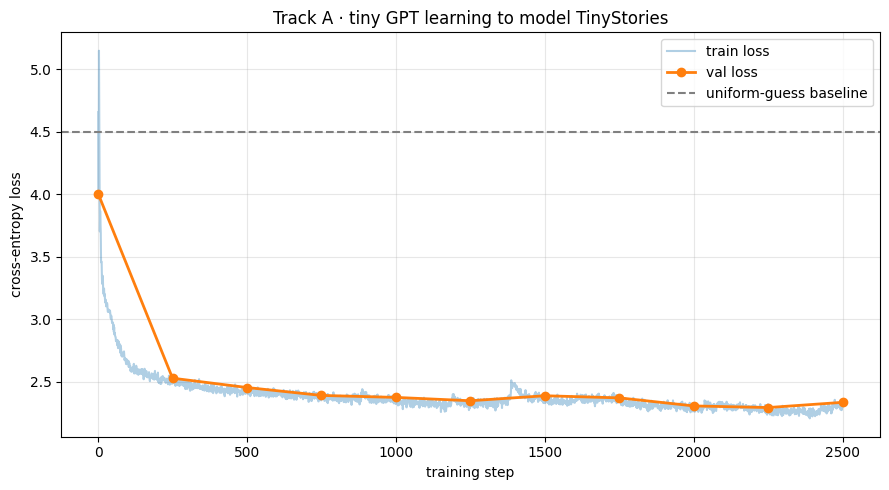

In [9]:
ts, tl = zip(*train_hist)
vs, vl = zip(*val_hist)
plt.figure(figsize=(9, 5))
plt.plot(ts, tl, alpha=0.35, label="train loss")
plt.plot(vs, vl, "o-", lw=2, label="val loss")
plt.axhline(math.log(vocab_size), ls="--", color="gray", label="uniform-guess baseline")
plt.xlabel("training step"); plt.ylabel("cross-entropy loss")
plt.title("Track A · tiny GPT learning to model TinyStories"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=120)   # saved alongside the notebook as a viewable artifact
plt.show()

## 7. Generate text

To generate, we feed the model a prompt, look at the logits for the *last* position, turn them into probabilities (`softmax`), and **sample** the next character. We append it and repeat — *autoregressive* generation, one character at a time. `temperature` controls randomness: low (0.5) = safe/repetitive, high (1.2) = wild/creative.

Remember: at this scale and runtime, expect *English-shaped nonsense* — real words and spacing emerge, full sense does not. Seeing words form at all, from a model that started knowing nothing, is the win.

In [10]:
def generate(prompt, n_new=400, temperature=0.7):
    idx = mx.array([encode(prompt)])
    for _ in range(n_new):
        logits = model(idx[:, -block_size:])[:, -1, :] / temperature
        next_id = mx.random.categorical(logits).reshape(1, 1)
        idx = mx.concatenate([idx, next_id], axis=1)
    return decode(idx[0].tolist())

print(generate("Once upon a time", n_new=400, temperature=0.7))

Once upon a time and at ang anded he sitho an hen le, t so arerrd f s t ferey bit te s an huns.






Once a bo a ha an was athi s nd t to, nome s th t us t the bone f t't so to the mulare ton t t he is theak. She ryoute as t that'wamand t het bain her te ace fathil.


Me andad theled t s s m t are they t thed ze am l athe?" he foy ale oy tthe s id b t the tokele.
Son, The ap annd il pe s s aly thecheng hed w a t


## 8. Your turn — "Try this", and what you just learned

**Levers to pull** (change the value in the hyperparameter cell, then re-run from there down — predict the effect first, then check):

1. **`temperature`** in the generate cell: try `0.4` then `1.1`. Low should look repetitive and "safe", high should look chaotic. *(cheapest experiment — no retraining)*
2. **`max_steps`** → `5000`: val loss should drop further and samples should have more real words. Costs more time.
3. **`n_layer`** → `2` then `6`: fewer layers train faster but plateau higher; more layers can reach lower loss but train slower.
4. **`learning_rate`** → `1e-2`: likely unstable (loss spikes or NaN) — a vivid lesson in why this knob matters.
5. **`block_size`** → `32`: less context; watch val loss settle higher.

**What you now understand end-to-end:**
- *Tokenization* — text ↔ integers (here, character-level).
- *Embeddings* — token id + position → vector.
- *Self-attention* — how positions share information, and why the causal mask matters.
- *The transformer block* — attention + MLP, with residuals and LayerNorm.
- *The training loop* — loss → gradients (backprop) → optimizer step.
- *The loss curve* — reading learning vs. overfitting.
- *Autoregressive sampling* — how text is generated, and what temperature does.

**Next (Track B):** we stop building from scratch and *fine-tune a real pre-trained model* (Qwen3-4B / Gemma 4 E2B) into TrialScout — where the same concepts (tokens, attention, loss, training loop) reappear, but now in service of a model that's actually useful. See `BACKLOG.md` → "Next".